# Import Packages, Import data, Clean table

In [7]:
#packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
from collections import Counter


#Import google analytics data
GoogleAnalytics = pd.read_csv("clean_GA.csv")

# Change the datatypes
GoogleAnalytics['event_date'] = pd.to_datetime(GoogleAnalytics['event_date'])
GoogleAnalytics['event_ts_utc'] = pd.to_datetime(GoogleAnalytics['event_ts_utc'], utc=True)

# drop NAs in the dataset
GoogleAnalytics = GoogleAnalytics.dropna(subset=['abandoned'])

## Helper Functions

In [8]:
def AnalyzeAvgTimeBetween(purchvar, category, eventName):
    # --- 0) Clean datatypes ---
    purch = purchvar[['event_ts_utc', 'purchase_segment']].copy()
    upd   = category[['event_ts_utc', 'purchase_segment']].copy()

    purch['event_ts_utc'] = pd.to_datetime(purch['event_ts_utc'], utc=True)
    upd['event_ts_utc']   = pd.to_datetime(upd['event_ts_utc'],   utc=True)
    purch['purchase_segment'] = purch['purchase_segment'].astype(str)
    upd['purchase_segment']   = upd['purchase_segment'].astype(str)

    # --- 1) Merge purchases and precursors within each segment ---
    merged = purch.merge(upd, on='purchase_segment', suffixes=('_purch', f'_{eventName}'))

    # --- 2) Keep only pairs where precursor happened before purchase ---
    merged = merged.loc[merged['event_ts_utc_purch'] > merged[f'event_ts_utc_{eventName}']].copy()

    # --- 3) (Optional) enforce same-year rule ---
    same_year = merged['event_ts_utc_purch'].dt.year == merged[f'event_ts_utc_{eventName}'].dt.year
    merged = merged.loc[same_year]

    # --- 4) Compute time differences in minutes ---
    merged['mins_between'] = (
        (merged['event_ts_utc_purch'] - merged[f'event_ts_utc_{eventName}'])
        .dt.total_seconds() / 60
    )

    # --- 5) Compute average time gap per segment ---
    out = (
        merged.groupby('purchase_segment', as_index=False)
              .agg(avg_mins_between=('mins_between', 'mean'),
                   num_pairs=('mins_between', 'size'))
              .sort_values('avg_mins_between', ascending=False)
    )

    # --- 6) Print diagnostic summary ---
    print(f"{eventName}: {len(out)} segments analyzed, mean gap (min) across segments = {out['avg_mins_between'].mean():.2f}")

    return out

# --- helpers ---
def top_counts(series, top_n=15):
    s = series.value_counts(dropna=False)
    total = s.sum()
    s = s.head(top_n)
    return pd.DataFrame({
        "pattern": s.index.to_list(),
        "count": s.values,
        "percent": (s.values / total * 100) if total else [0.0]*len(s)
    })

def stream_ngrams_count(seqs, n):
    c = Counter()
    for seq in seqs:
        if isinstance(seq, list) and len(seq) >= n:
            # update directly from a generator; no big intermediate list
            c.update(tuple(seq[i:i+n]) for i in range(len(seq)-n+1))
    return c

def top_ngrams_df(seqs, n=2, top_n=15):
    c = stream_ngrams_count(seqs, n)
    total = sum(c.values())
    rows = [(k, v, (v/total*100 if total else 0.0)) for k, v in c.most_common(top_n)]
    return pd.DataFrame(rows, columns=["pattern","count","percent"])

def compare_tables(df_a, df_b, label_a="abandoned", label_b="completed"):
    a = df_a.rename(columns={"count": f"count_{label_a}", "percent": f"percent_{label_a}"})
    b = df_b.rename(columns={"count": f"count_{label_b}",  "percent": f"percent_{label_b}"})
    # Outer join is fine on the already-small “top N” tables, not on the raw keys
    return a.merge(b, on="pattern", how="outer")

def describeEvents(out, SummaryTable,eventName):
    print(out['avg_mins_between'].describe())

    Perc75 = out['avg_mins_between'].describe()['75%']
    print("75% of purchases occured in less than", math.ceil(Perc75), "minute(s) of this event taking place.")

    Perc85 = out['avg_mins_between'].quantile(0.85)
    print("85% of purchases occured in less than", math.ceil(Perc85), "minute(s) of this event taking place.")

    Perc90 = out['avg_mins_between'].quantile(0.9)
    print("90% of purchases occured in less than", math.ceil(Perc90), "minute(s) of this event taking place.")

    SummaryTable.loc[SummaryTable['pattern'] == eventName, '75%'] = Perc75
    SummaryTable.loc[SummaryTable['pattern'] == eventName, '85%'] = Perc85

# --- 1) Segment-level status per (customer_id, purchase_segment) ---
# Priority: recovered > intermediate > not applicable (anything else)
def seg_status(s: pd.Series) -> str:
    sl = s.dropna().astype(str).str.lower()
    if (sl == 'recovered').any():
        return 'recovered'
    if (sl == 'intermediate').any():
        return 'intermediate'
    return 'not applicable'

# --- 3) Grouping logic:
# For each customer, assign a group_id so that
#   - each 'recovered' segment is the END of a group
#   - all PRECEDING consecutive 'intermediate' segments join that same group
#   - a recovered "resets" the run
# Implementation: reverse cumsum of recovered flags
def assign_groups(g: pd.DataFrame) -> pd.DataFrame:
    rec_flag = (g['status'] == 'recovered').astype(int)
    # reverse cumsum so rows before a recovered get same id as the recovered
    grp = rec_flag.iloc[::-1].cumsum().iloc[::-1]
    g = g.copy()
    g['group_id'] = grp
    return g

# --- 5) Build grouped sequences at the (customer_id, group_id) level ---
def collapse_runs(events):
    out, prev = [], object()
    for e in events:
        if e != prev:
            out.append(e)
        prev = e
    return out

# Helper function
def analyze_device(GA,columnName, device_label):
    df = GA[GA[columnName] == device_label]

    # --- Group and process ---
    seg = (
        df.groupby(['customer_id', 'purchase_segment'], as_index=False)
          .agg(
              start_ts=('event_ts_utc', 'min'),
              end_ts=('event_ts_utc', 'max'),
              status=('recovered', seg_status)
          )
    )
    seg = seg.sort_values(['customer_id', 'start_ts'])
    seg = seg.groupby('customer_id', group_keys=False).apply(assign_groups)
    seg_kept = seg[seg['group_id'] > 0].copy()

    df_labeled = df.merge(
        seg_kept[['customer_id', 'purchase_segment', 'group_id', 'status']],
        on=['customer_id', 'purchase_segment'],
        how='inner'
    )

    seq_df = (
        df_labeled.sort_values(['customer_id', 'group_id', 'event_ts_utc'])
        .groupby(['customer_id', 'group_id'], as_index=False)
        .agg(
            segments=('purchase_segment', lambda s: list(pd.unique(s))),
            group_status=('status', 'last'),
            start_ts=('event_ts_utc', 'min'),
            end_ts=('event_ts_utc', 'max'),
            num_events=('event_name', 'size'),
            sequence=('event_name', list),
        )
    )
    seq_df['sequence_collapsed'] = seq_df['sequence'].apply(collapse_runs)

    # --- Duration calculation ---
    seq_df['start_ts'] = pd.to_datetime(seq_df['start_ts'], utc=True, errors='coerce')
    seq_df['end_ts']   = pd.to_datetime(seq_df['end_ts'],   utc=True, errors='coerce')
    seq_df['duration'] = seq_df['end_ts'] - seq_df['start_ts']
    seq_df['duration_hours'] = seq_df['duration'].dt.total_seconds() / 3600
    dur = seq_df['duration_hours'].dropna().to_numpy()
    dur = dur[dur >= 0]

    # --- Duration summary ---
    print(f"\n=== Duration summary (hours) for {device_label} ===")
    print(seq_df['duration_hours'].describe())

    # --- ECDF ---
    p99 = np.percentile(dur, 99) if dur.size else 0.0
    xmax = p99 if np.isfinite(p99) and p99 > 0 else (dur.max() if dur.size else 1.0)
    x = np.sort(dur)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.figure()
    plt.step(x, y, where="post")
    plt.xlim(0, 7000)  # fixed x-axis limit
    plt.xlabel("Time to recovery (hours)")
    plt.ylabel("P(recovered by time ≤ t)")
    plt.title(f"Empirical chance of recovery over time for {device_label} users")
    plt.grid(True)
    plt.show()

    # --- Landmark probabilities ---
    landmarks = [1, 6, 12, 24, 48, 72]
    landmark_probs = {f"{h}h": float((dur <= h).mean()) for h in landmarks}
    out = pd.Series(landmark_probs, name=device_label).to_frame().T
    return out

def plot_recovery_summary(recovery_summary, title_suffix):
    # Ensure column order & numeric dtype
    cols = ['1h', '6h', '12h', '24h', '48h', '72h']
    recovery_summary = recovery_summary[cols].astype(float)

    # ---- Multi-line chart ----
    x_hours = [1, 6, 12, 24, 48, 72]
    x_labels = cols

    fig, ax = plt.subplots(figsize=(8, 5))
    for platform, row in recovery_summary.iterrows():
        ax.plot(x_hours, row.values, marker='o', linewidth=2, label=platform)

    ax.set_xticks(x_hours, x_labels)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time horizon")
    ax.set_ylabel("P(recovered by ≤ t)")
    ax.set_title(f"Recovery Probability {title_suffix}")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Platform", ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    # ---- Grouped bar chart ----
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_df = recovery_summary.T
    bar_df.plot(kind='bar', ax=ax)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time horizon")
    ax.set_ylabel("P(recovered by ≤ t)")
    ax.set_title(f"Recovery Probability {title_suffix} (Grouped Bars)")
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Q1 & Q2 Preparation

## Q1 -  What behavioral events or sequence of events are the strongest predictors of cart abandonment?

preparation steps to analyze what leads to cart abandonment:

1.  Filter out irrelevant rows to cart abandonment. This is done by removing rows where abandonment is labeled false because no purchase was made and no items were added to the cart. 
2.  Add the event_page_name to the event_name column for the "page_view" and "button_click" events in order to further contexualize and differentiate between different types of page views and button clicks.
3.  flatten the table to create bins of event sequences in each segment. One row will correlate with one segment and contain all the sequence of events that lead to a successful purchase or an abandoned cart.

Notes: As we saw in the EDA, an overwhelming number of event_names were "page_view" and "button_click". I decided to add the event_page_name to the event_name column for these two actions in order to further contexualize and differentiate between different types of page views and button clicks.

In [9]:
# step 1
GASimplified = GoogleAnalytics[~((GoogleAnalytics['abandoned'] == False) & (GoogleAnalytics['False_by_purchase'] == 'no purchase'))]

# step 2
mask = GASimplified['event_name'].isin(['page_view', 'button_click'])
GASimplified.loc[mask, 'event_name'] = (
    GASimplified.loc[mask, 'event_name'].fillna('') + ' - ' +
    GASimplified.loc[mask, 'event_page_name'].fillna('')
)

# step 3
GASequenceMining = GASimplified.sort_values(['purchase_segment', 'event_ts_utc'])

# Build the sequence of events per segment
seq_dfP1 = (
    GASequenceMining
    .groupby('purchase_segment')
    .agg(
        customer_id=('customer_id', 'first'),
        abandoned=('abandoned', 'first'),
        sequence=('event_name', list),
        start_ts=('event_ts_utc', 'min'),
        end_ts=('event_ts_utc', 'max'),
        num_events=('event_name', 'size')
    )
    .reset_index()
)

# (Optional) Collapse consecutive duplicates within each sequence (reduces noise like repeated page_view,page_view)
def collapse_runs(events):
    out = []
    prev = object()
    for e in events:
        if e != prev:
            out.append(e)
        prev = e
    return out

seq_dfP1['sequence_collapsed'] = seq_dfP1['sequence'].apply(collapse_runs)

## Q2 - What behaviors or conditions lead to a customer returning to complete a previously abandoned cart?

Steps to preparing for modeling what behaviors or conditions lead to cart recovery

1.  Figure out the current rate of cart recovery. 
2.  Filter only for rows that are labeled intermediate or recovery in the recovered column. 'recovery' indicates the segment where an abandoned cart was checked out, and 'intermediate' indicates the segments between an abandoned and recovered cart 
3.  flatten the table to create bins of event sequences in each segment. One row will correlate each recovery and it's preceding intermediate rows. 


In [10]:
# part 1
GAFlat = (GoogleAnalytics.groupby('purchase_segment', as_index=False).last())
num_abandoned = (GAFlat['abandoned'] == True).sum()
num_recovered = (GAFlat['recovered'] == 'recovered').sum()

ratio = num_recovered / num_abandoned
pct = ratio * 100

print(f"{pct:.2f}% (recovered of abandoned carts)")

# part 2
GARecovered = GoogleAnalytics[((GoogleAnalytics['recovered'] == 'recovered') | (GoogleAnalytics['recovered'] == 'intermediate'))]

mask = GARecovered['event_name'].isin(['page_view', 'button_click'])
GARecovered.loc[mask, 'event_name'] = (
    GARecovered.loc[mask, 'event_name'].fillna('') + ' - ' +
    GARecovered.loc[mask, 'event_page_name'].fillna('')
)


# part 3

GA = GARecovered.copy()

seg = (
    GA.groupby(['customer_id', 'purchase_segment'], as_index=False)
      .agg(
          start_ts=('event_ts_utc', 'min'),
          end_ts=('event_ts_utc', 'max'),
          status=('recovered', seg_status)
      )
)

# --- 2) Order segments within each customer chronologically ---
seg = seg.sort_values(['customer_id', 'start_ts'])

seg = seg.groupby('customer_id', group_keys=False).apply(assign_groups)

seg_kept = seg[seg['group_id'] > 0].copy()

GA_labeled = GA.merge(
    seg_kept[['customer_id', 'purchase_segment', 'group_id', 'status']],
    on=['customer_id', 'purchase_segment'],
    how='inner'  # only events that belong to a recovered-anchored group
)

seq_dfP2 = (
    GA_labeled
      .sort_values(['customer_id', 'group_id', 'event_ts_utc'])
      .groupby(['customer_id', 'group_id'], as_index=False)
      .agg(
          segments=('purchase_segment', lambda s: list(pd.unique(s))),
          group_status=('status', 'last'),           # will be 'recovered'
          start_ts=('event_ts_utc', 'min'),
          end_ts=('event_ts_utc', 'max'),
          num_events=('event_name', 'size'),
          sequence=('event_name', list),
      )
)

seq_dfP2['sequence_collapsed'] = seq_dfP2['sequence'].apply(collapse_runs)


53.57% (recovered of abandoned carts)


# Q1 and Q2 Modeling

# Q1 -  What behavioral events or sequence of events are the strongest predictors of cart abandonment?

Steps to assess what leads to cart abandonment:

1.  Perform sequence mining on to discover the top first events, last events, bigrams, trigrams, and full sequences that lead to cart abandonment. 
2.  Extract and Analyze the top 10 events or sequence of events that lead to the highest percentage of cart abandonment and append them to a single table for analysis.
3.  Use the results of the time-distance-from-purchase analysis to inform when Swire should reach out to customers after each event is clicked to remind them they have items in their cart. 


## Part 1

In [11]:
# Part 1
# --- split once with boolean masks (no .copy() unless you need it) ---
mask_abd = seq_dfP1["abandoned"].astype(bool)
seqs_abd = seq_dfP1.loc[mask_abd, "sequence"]
seqs_cmp = seq_dfP1.loc[~mask_abd, "sequence"]

# 1) first/last events (vectorized)
first_abd  = top_counts(seqs_abd.str[0], top_n=10)
first_cmp  = top_counts(seqs_cmp.str[0], top_n=10)
last_abd   = top_counts(seqs_abd.str[-1], top_n=10)
last_cmp   = top_counts(seqs_cmp.str[-1], top_n=10)

first_events = compare_tables(first_abd, first_cmp)
last_events  = compare_tables(last_abd, last_cmp)

# 2) full sequences (exact)
# Turn lists -> tuples with a vectorized-ish map once, then value_counts
full_abd = top_counts(seqs_abd.map(lambda s: tuple(s) if isinstance(s, list) else ()), top_n=10)
full_cmp = top_counts(seqs_cmp.map(lambda s: tuple(s) if isinstance(s, list) else ()), top_n=10)
full_sequences = compare_tables(full_abd, full_cmp)

# 3) bigrams / trigrams (streamed; no giant intermediates)
bigrams_abd   = top_ngrams_df(seqs_abd, n=2, top_n=10)
bigrams_cmp   = top_ngrams_df(seqs_cmp, n=2, top_n=10)
trigrams_abd  = top_ngrams_df(seqs_abd, n=3, top_n=10)
trigrams_cmp  = top_ngrams_df(seqs_cmp, n=3, top_n=10)

bigrams  = compare_tables(bigrams_abd,  bigrams_cmp)
trigrams = compare_tables(trigrams_abd, trigrams_cmp)

# Example: show heads for a quick peek (comment out if running in a non-notebook environment)
print("\nTop FIRST events (abandoned vs completed):")
display(first_events.head(15))

print("\nTop LAST events (abandoned vs completed):")
display(last_events.head(15))

print("\nTop FULL sequences (abandoned vs completed):")
display(full_sequences.head(10))

print("\nTop BIGRAMS (abandoned vs completed):")
display(bigrams.head(15))

print("\nTop TRIGRAMS (abandoned vs completed):")
display(trigrams.head(15))


Top FIRST events (abandoned vs completed):


,pattern,count_abandoned,percent_abandoned,count_completed,percent_completed
0,page_view - Mycoke Dashboard,2805.0,70.797577,17933.0,55.408620
1,session_start,261.0,6.587582,2026.0,6.259849
2,page_view - Mycoke Orders - Purchase Success,233.0,5.880868,3935.0,12.158196
3,page_view - Mycoke Orders,131.0,3.306411,1897.0,5.861270
4,page_view - Unknown Page,116.0,2.927814,976.0,3.015603
5,nav_link_click,59.0,1.489147,691.0,2.135022
6,button_click - Mycoke Dashboard,54.0,1.362948,NaN,NaN
7,page_view - Mycoke Order History,47.0,1.186270,640.0,1.977445
8,first_visit,43.0,1.085310,NaN,NaN
9,user_engagement,41.0,1.034831,559.0,1.727174



Top LAST events (abandoned vs completed):


,pattern,count_abandoned,percent_abandoned,count_completed,percent_completed
0,update_cart,1027.0,25.921252,58.0,0.179206
1,remove_from_cart,318.0,8.026249,NaN,NaN
2,view_item_list,295.0,7.445734,NaN,NaN
3,page_view - Unknown Page,274.0,6.915699,NaN,NaN
4,page_view - Mycoke Dashboard,226.0,5.704190,NaN,NaN
5,user_engagement,226.0,5.704190,NaN,NaN
6,button_click - Mycoke Orders - Cart,216.0,5.451792,NaN,NaN
7,page_view - Mycoke Orders,170.0,4.290762,NaN,NaN
8,button_click - Mycoke Orders - Checkout: Revie...,126.0,3.180212,53.0,0.163757
9,proceed_to_checkout,126.0,3.180212,NaN,NaN



Top FULL sequences (abandoned vs completed):


,pattern,count_abandoned,percent_abandoned,count_completed,percent_completed
0,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
1,"(page_view - Mycoke Dashboard, view_promotion,...",1.0,0.02524,NaN,NaN
2,"(page_view - Mycoke Dashboard, session_start, ...",1.0,0.02524,NaN,NaN
3,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
4,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
5,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
6,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
7,"(page_view - Mycoke Orders - Purchase Success,...",1.0,0.02524,NaN,NaN
8,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
9,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN



Top BIGRAMS (abandoned vs completed):


,pattern,count_abandoned,percent_abandoned,count_completed,percent_completed
0,"(view_item_list, view_item_list)",30972.0,7.592591,164818.0,6.225550
1,"(page_view - Mycoke Dashboard, page_view - Myc...",13047.0,3.198390,73127.0,2.762173
2,"(page_view - Mycoke Orders, page_view - Mycoke...",11142.0,2.731391,76082.0,2.873790
3,"(view_item_list, button_click - Mycoke Orders)",10603.0,2.599259,65954.0,2.491232
4,"(button_click - Mycoke Orders, button_click - ...",10453.0,2.562487,51764.0,1.955244
5,"(page_view - Unknown Page, page_view - Unknown...",8616.0,2.112158,46839.0,1.769215
6,"(button_click - Mycoke Orders, view_item_list)",8472.0,2.076857,51994.0,1.963931
7,"(page_view - Mycoke Orders, view_item_list)",7889.0,1.933939,47661.0,1.800264
8,"(view_item_list, add_to_cart)",7340.0,1.799355,56285.0,2.126012
9,"(add_to_cart, add_to_cart)",7123.0,1.746159,NaN,NaN



Top TRIGRAMS (abandoned vs completed):


,pattern,count_abandoned,percent_abandoned,count_completed,percent_completed
0,"(view_item_list, view_item_list, view_item_list)",13698.0,3.390913,62943.0,2.406924
1,"(button_click - Mycoke Orders, button_click - ...",5993.0,1.483555,26239.0,1.003373
2,"(view_item_list, view_item_list, button_click ...",4871.0,1.205806,27910.0,1.067271
3,"(page_view - Mycoke Dashboard, page_view - Myc...",4786.0,1.184765,28180.0,1.077596
4,"(page_view - Mycoke Orders, view_item_list, vi...",4049.0,1.002322,22426.0,0.857565
5,"(view_item_list, button_click - Mycoke Orders,...",3968.0,0.982271,23369.0,0.893625
6,"(add_to_cart, add_to_cart, add_to_cart)",3644.0,0.902065,NaN,NaN
7,"(button_click - Mycoke Orders, view_item_list,...",3451.0,0.854288,NaN,NaN
8,"(view_item_list, view_item_list, add_to_cart)",3360.0,0.831761,23882.0,0.913242
9,"(view_item_list, button_click - Mycoke Orders,...",3331.0,0.824583,NaN,NaN


## Part 2

In [12]:
# Create SummaryTable from the top LAST events output
SummaryTable = last_events.loc[
    last_events['percent_abandoned'].notna(), 
    ['pattern', 'percent_abandoned']
].copy()

# Add blank (empty) columns for 75% and 85%
SummaryTable['75%'] = ''
SummaryTable['85%'] = ''
SummaryTable.head(n=10)

,pattern,percent_abandoned,75%,85%
0,update_cart,25.921252,,
1,remove_from_cart,8.026249,,
2,view_item_list,7.445734,,
3,page_view - Unknown Page,6.915699,,
4,page_view - Mycoke Dashboard,5.704190,,
5,user_engagement,5.704190,,
6,button_click - Mycoke Orders - Cart,5.451792,,
7,page_view - Mycoke Orders,4.290762,,
8,button_click - Mycoke Orders - Checkout: Revie...,3.180212,,
9,proceed_to_checkout,3.180212,,


Results: 
1. The top first events aren't very helpful as it indicates session_starts, dahsboards visits, and purchase success pages from previous purchases. Not much insight can be gleaned from this
2. The top last events are where the most information can be collected. As we can see above, 70% of the instances of cart abandonment we identified above can be explained by these features. Most notably, update_cart. 
3. The full sequences, bigrams, and trigams are not very helpful in predicting cart abandonment. The full sequences are too unique as there isn't a single duplicate pattern identified. The bigrams and trigrams are mostly standard website clicks and don't represent enough of the abandoned dataset.

## Step 3

Analyze the results for each event and append the results to our summary table.

In [13]:
# Part 5
# create purchases table
purchases = GASimplified.loc[
    (GASimplified['event_name'] == 'purchase') &
    (GASimplified['abandoned'] != True)&
    (GASimplified['recovered'] != 'recovered'),
    ['event_name', 'event_ts_utc', 'purchase_segment']
]

# update_cart
update_carts = GASimplified.loc[GASimplified['event_name'] == 'update_cart', ['event_name', 'event_ts_utc', 'purchase_segment']]
out = AnalyzeAvgTimeBetween(purchases,update_carts,'update_cart')
describeEvents(out,SummaryTable,'update_cart')

# remove_from_cart
remove_from_cart = GASimplified.loc[GASimplified['event_name'] == 'remove_from_cart', ['event_name', 'event_ts_utc', 'purchase_segment']]
out = AnalyzeAvgTimeBetween(purchases,remove_from_cart,'remove_from_cart')
describeEvents(out,SummaryTable,'remove_from_cart')

# Analyze view_item_list
view_item_list = GASimplified.loc[GASimplified['event_name'] == 'view_item_list', ['event_name', 'event_ts_utc', 'purchase_segment']]
out = AnalyzeAvgTimeBetween(purchases,view_item_list,'view_item_list')
describeEvents(out,SummaryTable,'view_item_list')

# page_view - Unknown Page
unknown = GASimplified.loc[GASimplified['event_name'] == 'page_view - Unknown Page', ['event_name', 'event_ts_utc', 'purchase_segment']]
out = AnalyzeAvgTimeBetween(purchases,unknown,'page_view - Unknown Page')
describeEvents(out,SummaryTable,'page_view - Unknown Page')

# page_view - Mycoke Dashboard
myCokeDash = GASimplified.loc[GASimplified['event_name'] == 'page_view - Mycoke Dashboard', ['event_name', 'event_ts_utc', 'purchase_segment']]
out = AnalyzeAvgTimeBetween(purchases,myCokeDash,'page_view - Mycoke Dashboard')
describeEvents(out,SummaryTable,'page_view - Mycoke Dashboard')

# Analyze user_engagement
user_engagement = GASimplified.loc[GASimplified['event_name'] == 'user_engagement', ['event_name', 'event_ts_utc', 'purchase_segment']]
out = AnalyzeAvgTimeBetween(purchases,user_engagement,'user_engagement')
describeEvents(out,SummaryTable,'user_engagement')

# button_click - Mycoke Orders - Cart
ordersCart = GASimplified.loc[GASimplified['event_name'] == 'button_click - Mycoke Orders - Cart', ['event_name', 'event_ts_utc', 'purchase_segment']]
out = AnalyzeAvgTimeBetween(purchases,ordersCart,'button_click - Mycoke Orders - Cart')
describeEvents(out,SummaryTable,'button_click - Mycoke Orders - Cart')

# page_view - Mycoke Orders
orders = GASimplified.loc[GASimplified['event_name'] == 'page_view - Mycoke Orders', ['event_name', 'event_ts_utc', 'purchase_segment']]
out = AnalyzeAvgTimeBetween(purchases,orders,'page_view - Mycoke Orders')
describeEvents(out,SummaryTable,'page_view - Mycoke Orders')

# button_click - Mycoke Orders - Checkout: Review Order
revieworder = GASimplified.loc[GASimplified['event_name'] == 'button_click - Mycoke Orders - Checkout: Review Order', ['event_name', 'event_ts_utc', 'purchase_segment']]
out = AnalyzeAvgTimeBetween(purchases,revieworder,'button_click - Mycoke Orders - Checkout: Review Order')
describeEvents(out,SummaryTable,'button_click - Mycoke Orders - Checkout: Review Order')

# Analyze proceed_to_checkout
proceed_to_checkout = GASimplified.loc[GASimplified['event_name'] == 'proceed_to_checkout', ['event_name', 'event_ts_utc', 'purchase_segment']]
out = AnalyzeAvgTimeBetween(purchases,proceed_to_checkout,'proceed_to_checkout')
describeEvents(out,SummaryTable,'proceed_to_checkout')

# Part 6
SummaryTable[['75%', '85%']] = (SummaryTable[['75%', '85%']].astype(float) / 60).round(0)
display(SummaryTable.head(n=10))
total75 = SummaryTable.loc[SummaryTable['75%'] < 24, 'percent_abandoned'].sum()
print("Please refer to the chart above to see which event_names correlate with a 75% chance of purcase within one day of happening. We can potentially reduce cart abandonment by",round(total75,0),"percent if we reach out to customers who enter any of these events and dont purchase within a day.")
total85 = SummaryTable.loc[SummaryTable['85%'] < 24, 'percent_abandoned'].sum()
print("Please refer to the chart above to see which event_names correlate with a 85% chance of purcase within one day of happening. We can potentially reduce cart abandonment by",round(total85,0),"percent if we reach out to customers who enter any of these events and dont purchase within a day.")


update_cart: 28414 segments analyzed, mean gap (min) across segments = 388.95
count     28414.000000
mean        388.951014
std        2638.513573
min           0.001033
25%           0.527602
50%           1.298703
75%           4.841303
max      143522.640448
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 5 minute(s) of this event taking place.
85% of purchases occured in less than 21 minute(s) of this event taking place.
90% of purchases occured in less than 336 minute(s) of this event taking place.
remove_from_cart: 9609 segments analyzed, mean gap (min) across segments = 911.52
count      9609.000000
mean        911.518794
std        3947.312432
min           0.173900
25%           1.785933
50%           4.695350
75%          21.616077
max      116537.310455
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 22 minute(s) of this event taking place.
85% of purchases occured in less than 286 minute(s) of this event taking place

,pattern,percent_abandoned,75%,85%
0,update_cart,25.921252,0.0,0.0
1,remove_from_cart,8.026249,0.0,5.0
2,view_item_list,7.445734,7.0,36.0
3,page_view - Unknown Page,6.915699,15.0,61.0
4,page_view - Mycoke Dashboard,5.704190,18.0,60.0
5,user_engagement,5.704190,49.0,84.0
6,button_click - Mycoke Orders - Cart,5.451792,0.0,12.0
7,page_view - Mycoke Orders,4.290762,23.0,68.0
8,button_click - Mycoke Orders - Checkout: Revie...,3.180212,0.0,0.0
9,proceed_to_checkout,3.180212,0.0,0.0


Please refer to the chart above to see which event_names correlate with a 75% chance of purcase within one day of happening. We can potentially reduce cart abandonment by 70.0 percent if we reach out to customers who enter any of these events and dont purchase within a day.
Please refer to the chart above to see which event_names correlate with a 85% chance of purcase within one day of happening. We can potentially reduce cart abandonment by 46.0 percent if we reach out to customers who enter any of these events and dont purchase within a day.


Events that on average have a 75% of a purchase taking place within one day of being executed. These are the last events in 70% of abandoned cart segments:
1. update_cart
2. remove_from_cart
3. view_item_list
4. page_view - Unknown Page
5. page_view - Mycoke Dashboard	
6. button_click - Mycoke Orders - Cart
7. page_view - Mycoke Orders
8. button_click - Mycoke Orders - Checkout: Review Order
9. proceed_to_checkout

Events that on average have a 85% of a purchase taking place within one day of being executed. These are the last events in 46% of abandoned cart segments:
1. update_cart
2. remove_from_cart
3. button_click - Mycoke Orders - Cart
4. button_click - Mycoke Orders - Checkout: Review Order
5. proceed_to_checkout

# Q2 - What behaviors or conditions lead to a customer returning to complete a previously abandoned cart?

Steps to model what leads to cart recovery:

1.  Analyze event names for sequence mining to understand if certain events or chain of events influence recovery
2.  Perform analysis to unlock the length of time it takes for all recoveries to take place
3.  Perform analysis on each device type to understand the length of time recovery takes by device type.

## Step 1

In [14]:
# --- focus ONLY on recovered segments ---
if 'group_status' in seq_dfP2.columns:
    mask_rec = seq_dfP2['group_status'].astype(str).str.lower().eq('recovered')
elif 'recovered' in seq_dfP2.columns:
    mask_rec = seq_dfP2['recovered'].astype(str).str.lower().eq('recovered')
else:
    raise KeyError("seq_df needs a 'group_status' or 'recovered' column to identify recovered segments.")

seqs_rec = seq_dfP2.loc[mask_rec, 'sequence']

# 1) first / last events (vectorized)
first_rec = top_counts(seqs_rec.str[0], top_n=15)
last_rec  = top_counts(seqs_rec.str[-1], top_n=15)

# 2) full sequences (exact)
full_rec = top_counts(
    seqs_rec.map(lambda s: tuple(s) if isinstance(s, list) else ()),
    top_n=10
)

# 3) bigrams / trigrams (streamed)
bigrams_rec  = top_ngrams_df(seqs_rec, n=2, top_n=15)
trigrams_rec = top_ngrams_df(seqs_rec, n=3, top_n=15)

# --- quick peek ---
print("\nTop FIRST events (recovered only):")
display(first_rec.head(15))

print("\nTop LAST events (recovered only):")
display(last_rec.head(15))

print("\nTop FULL sequences (recovered only):")
display(full_rec.head(10))

print("\nTop BIGRAMS (recovered only):")
display(bigrams_rec.head(15))

print("\nTop TRIGRAMS (recovered only):")
display(trigrams_rec.head(15))


Top FIRST events (recovered only):


,pattern,count,percent
0,page_view - Mycoke Dashboard,1574,74.140367
1,session_start,220,10.362694
2,page_view - Mycoke Orders,59,2.779086
3,page_view - Mycoke Orders - Cart,54,2.543570
4,page_view - Unknown Page,54,2.543570
5,button_click - Mycoke Dashboard,43,2.025436
6,nav_link_click,20,0.942063
7,view_item_list,14,0.659444
8,first_visit,12,0.565238
9,login,11,0.518135



Top LAST events (recovered only):


,pattern,count,percent
0,purchase,1954,92.039567
1,ordersuccesspage_displayed,74,3.485634
2,page_view - Mycoke Orders - Purchase Success,74,3.485634
3,page_view - Mycoke Orders - Checkout: Review O...,19,0.894960
4,update_cart,1,0.047103
5,session_start,1,0.047103



Top FULL sequences (recovered only):


,pattern,count,percent
0,"(page_view - Mycoke Orders, nav_link_click, pa...",1,0.047103
1,"(page_view - Mycoke Dashboard, page_view - Myc...",1,0.047103
2,"(page_view - Mycoke Orders, page_view - Mycoke...",1,0.047103
3,"(page_view - Mycoke Dashboard, page_view - Myc...",1,0.047103
4,"(button_click - Mycoke Dashboard, page_view - ...",1,0.047103
5,"(page_view - Mycoke Dashboard, page_view - Myc...",1,0.047103
6,"(page_view - Mycoke Dashboard, page_view - Myc...",1,0.047103
7,"(page_view - Mycoke Dashboard, button_click - ...",1,0.047103
8,"(button_click - Mycoke Dashboard, page_view - ...",1,0.047103
9,"(page_view - Mycoke Dashboard, page_view - Myc...",1,0.047103



Top BIGRAMS (recovered only):


,pattern,count,percent
0,"(view_item_list, view_item_list)",15674,6.131638
1,"(page_view - Mycoke Dashboard, page_view - Myc...",7126,2.787677
2,"(button_click - Mycoke Orders, button_click - ...",6457,2.525966
3,"(view_item_list, button_click - Mycoke Orders)",5836,2.283032
4,"(page_view - Mycoke Orders, page_view - Mycoke...",5124,2.004499
5,"(update_cart, update_cart)",4933,1.929780
6,"(page_view - Mycoke Orders - Cart, update_cart)",4808,1.880880
7,"(button_click - Mycoke Orders, view_item_list)",4758,1.861320
8,"(view_item_list, add_to_cart)",4586,1.794034
9,"(add_to_cart, add_to_cart)",3879,1.517457



Top TRIGRAMS (recovered only):


,pattern,count,percent
0,"(view_item_list, view_item_list, view_item_list)",6319,2.492683
1,"(button_click - Mycoke Orders, button_click - ...",4069,1.605116
2,"(page_view - Mycoke Dashboard, page_view - Myc...",2867,1.130958
3,"(view_item_list, view_item_list, button_click ...",2589,1.021294
4,"(page_view - Mycoke Orders - Cart, page_view -...",2351,0.927409
5,"(view_item_list, button_click - Mycoke Orders,...",2163,0.853248
6,"(view_item_list, view_item_list, add_to_cart)",2104,0.829974
7,"(page_view - Mycoke Orders - Cart, update_cart...",2037,0.803544
8,"(page_view - Mycoke Orders, view_item_list, vi...",1897,0.748318
9,"(button_click - Mycoke Orders, view_item_list,...",1846,0.728199


As we can see from the sequence mining results above, there isn't much insight we can gather. the results are similar to the abandonment results, except the last events are less insightful since 92% are purchase (which makes sense). We should focus on understanding time as a factor for cart recovery

## Step 2

### Step 2.1 Analzye all time-based results for cart recovery

In [15]:
# Ensure timestamps are datetime64[ns, UTC]
seq_dfP2['start_ts'] = pd.to_datetime(seq_dfP2['start_ts'], utc=True, errors='coerce')
seq_dfP2['end_ts']   = pd.to_datetime(seq_dfP2['end_ts'],   utc=True, errors='coerce')

# 1) Compute duration as a timedelta
seq_dfP2['duration'] = seq_dfP2['end_ts'] - seq_dfP2['start_ts']

# 2) Extract in various units for convenience
seq_dfP2['duration_hours'] = seq_dfP2['duration'].dt.total_seconds() / 3600
seq_dfP2['duration_days']  = seq_dfP2['duration'].dt.total_seconds() / 86400
seq_dfP2['duration_minutes'] = seq_dfP2['duration'].dt.total_seconds() / 60

# 3) Quick descriptive statistics
print("\n=== Duration summary (hours) ===")
print(seq_dfP2['duration_hours'].describe())

# 4) Optional: aggregate by customer or group_status
summary = (
    seq_dfP2.groupby('group_status')['duration_hours']
    .describe(percentiles=[.25, .5, .75])
    .round(2)
)
print("\n=== Duration by group_status ===")
print(summary)

# 5) Optional: identify longest/shortest recovered sequences
longest = seq_dfP2.nlargest(5, 'duration_hours')[['customer_id','group_id','duration_hours','num_events']]
shortest = seq_dfP2.nsmallest(5, 'duration_hours')[['customer_id','group_id','duration_hours','num_events']]

print("\nLongest recovered sequences:")
display(longest)

print("\nShortest recovered sequences:")
display(shortest)


=== Duration summary (hours) ===
count    2123.000000
mean      263.667861
std       736.973221
min         0.003971
25%         0.141561
50%         1.621970
75%       168.073646
max      7038.238264
Name: duration_hours, dtype: float64

=== Duration by group_status ===
               count    mean     std  min   25%   50%     75%      max
group_status                                                          
recovered     2123.0  263.67  736.97  0.0  0.14  1.62  168.07  7038.24

Longest recovered sequences:


,customer_id,group_id,duration_hours,num_events
467,501282634,1,7038.238264,40
1932,600253379,1,6687.545036,490
1182,501666952,1,6029.466157,195
281,501034697,1,5902.973171,161
2014,600555186,1,5902.114968,145



Shortest recovered sequences:


,customer_id,group_id,duration_hours,num_events
680,501463566,3,0.003971,9
1701,600054413,2,0.005888,10
499,501336609,1,0.009331,20
1170,501665019,3,0.009992,16
342,501109872,1,0.011717,21


### Step 2.2 Plot histograms with 90th percentile and first bin identification

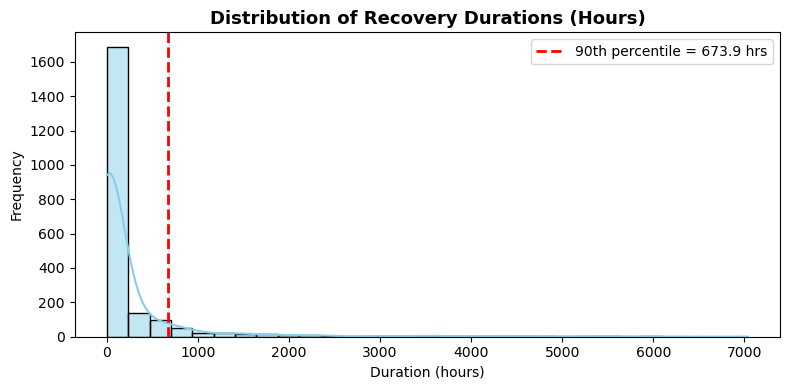

Total observations: 2,123
Number of observations in first bin: 1,687 (79.46% of total)
Duration range of first bin: 0.00 to 234.61 hours


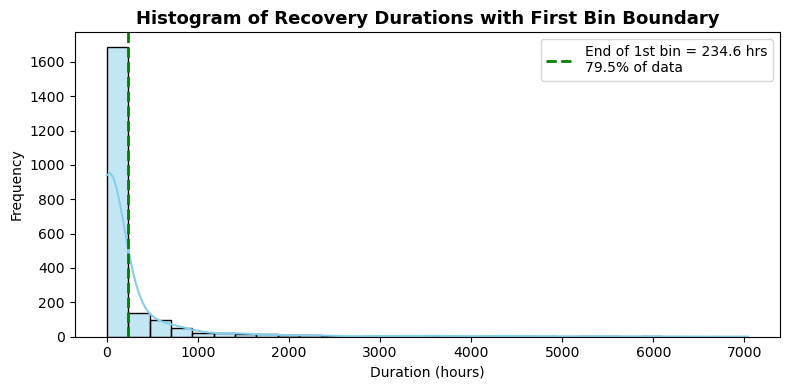

In [16]:
# Ensure duration_hours column exists
seq_dfP2['start_ts'] = pd.to_datetime(seq_dfP2['start_ts'], utc=True, errors='coerce')
seq_dfP2['end_ts']   = pd.to_datetime(seq_dfP2['end_ts'], utc=True, errors='coerce')
seq_dfP2['duration_hours'] = (seq_dfP2['end_ts'] - seq_dfP2['start_ts']).dt.total_seconds() / 3600

# Filter valid durations
durations = seq_dfP2.loc[seq_dfP2['duration_hours'] > 0, 'duration_hours']

# Calculate 90th percentile
p90 = durations.quantile(0.90)

# --- Histogram ---
plt.figure(figsize=(8, 4))
sns.histplot(durations, bins=30, kde=True, color='skyblue')

# Add the 90th percentile line
plt.axvline(p90, color='red', linestyle='--', linewidth=2, label=f"90th percentile = {p90:.1f} hrs")

# Add title and labels
plt.title("Distribution of Recovery Durations (Hours)", fontsize=13, weight='bold')
plt.xlabel("Duration (hours)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

#------------------------------------------------------------------------------------------------------------------

# Assuming durations is already defined
durations = seq_dfP2.loc[seq_dfP2['duration_hours'] > 0, 'duration_hours']

# --- Recreate histogram to get bin edges and counts ---
counts, bin_edges = np.histogram(durations, bins=30)

# --- 1) Extract first bin stats ---
first_bin_count = int(counts[0])
first_bin_start = bin_edges[0]
first_bin_end   = bin_edges[1]
first_bin_range = (first_bin_start, first_bin_end)

# --- 2) Compute percentage ---
total_obs = int(counts.sum())
first_bin_pct = (first_bin_count / total_obs * 100) if total_obs else 0.0

# --- 3) Print results ---
print(f"Total observations: {total_obs:,}")
print(f"Number of observations in first bin: {first_bin_count:,} "
      f"({first_bin_pct:.2f}% of total)")
print(f"Duration range of first bin: {first_bin_range[0]:.2f} to {first_bin_range[1]:.2f} hours")

# --- 4) Optional visualization ---
plt.figure(figsize=(8,4))
sns.histplot(durations, bins=30, kde=True, color='skyblue')
plt.axvline(first_bin_end, color='green', linestyle='--', linewidth=2,
            label=(f"End of 1st bin = {first_bin_end:.1f} hrs\n"
                   f"{first_bin_pct:.1f}% of data"))
plt.title("Histogram of Recovery Durations with First Bin Boundary", fontsize=13, weight='bold')
plt.xlabel("Duration (hours)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Step 2.3 plot chance of recovery over time for all customers

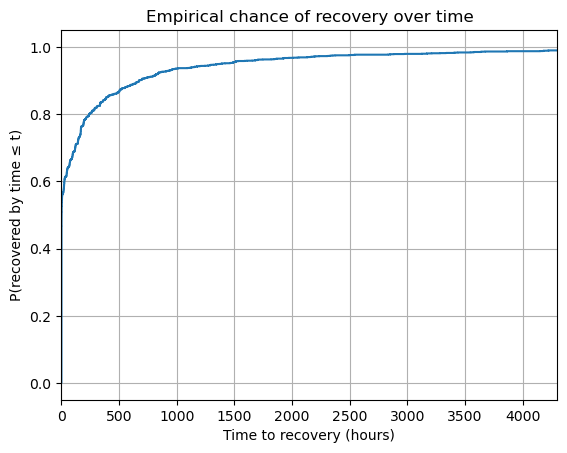

,P(recovered by ≤ t)
1h,0.470561
6h,0.554404
12h,0.563354
24h,0.592558
48h,0.629298
72h,0.653792


In [17]:
# --- Assumes seq_df already has duration computed as in your snippet ---
dur = seq_dfP2['duration_hours'].dropna().to_numpy()
dur = dur[dur >= 0]  # guard against negatives

# Percentile cap for readability
p99 = np.percentile(dur, 99) if dur.size else 0.0
xmax = p99 if np.isfinite(p99) and p99 > 0 else (dur.max() if dur.size else 1.0)

# ===== 1) ECDF: P(recovered within ≤ t) =====
x = np.sort(dur)
y = np.arange(1, len(x) + 1) / len(x)

plt.figure()
plt.step(x, y, where="post")
plt.xlim(0, xmax)
plt.xlabel("Time to recovery (hours)")
plt.ylabel("P(recovered by time ≤ t)")
plt.title("Empirical chance of recovery over time")
plt.grid(True)
plt.show()

# ===== 3) Quick landmarks =====
landmarks = [1, 6, 12, 24, 48, 72]
landmark_probs = {f"{h}h": float((dur <= h).mean()) for h in landmarks}
pd.Series(landmark_probs, name="P(recovered by ≤ t)").to_frame()

We can see very clearly that there is a steep chance of prolongued abandonment over time. Summarized results below:
    50% of carts are recovered in 2 hours.
    65% of carts are recovered in 3 days.
    75% of carts are recovered in 168 hours, or 7 days.
    80% of carts are recovered in 235 hours, or 10 days.
    90% of carts are recovered in 674 hours, or 28 days. 
    
It appears that the steep drop off in recovery over time shows that abandonment is intentional. Customers either return to their carts, or they move on and wait until they need inventory. 

## Step 3 Rate of recovery by device type

### Step 3.1 Rate of recovery by device_category


=== Duration summary (hours) for Desktop ===
count    1758.000000
mean      216.447416
std       587.054459
min         0.000000
25%         0.137522
50%         1.180945
75%       157.417586
max      5424.963747
Name: duration_hours, dtype: float64


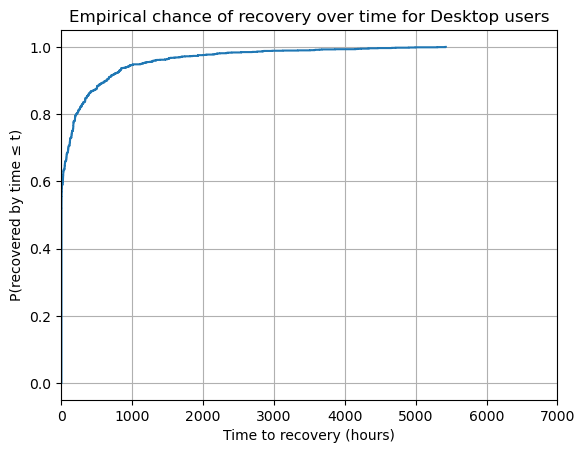


=== Duration summary (hours) for Mobile ===
count     441.000000
mean      310.613355
std       964.937172
min         0.000000
25%         0.081600
50%         0.402051
75%       125.048389
max      7038.238264
Name: duration_hours, dtype: float64


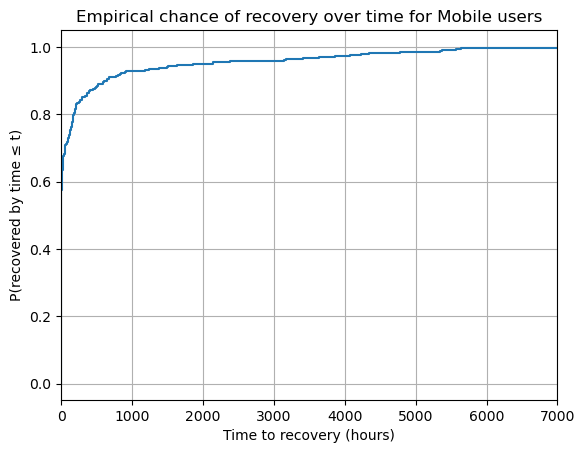


=== Duration summary (hours) for Tablet ===
count      29.000000
mean      144.580914
std       513.494213
min         0.000000
25%         0.065722
50%         0.237912
75%       101.274572
max      2756.284937
Name: duration_hours, dtype: float64


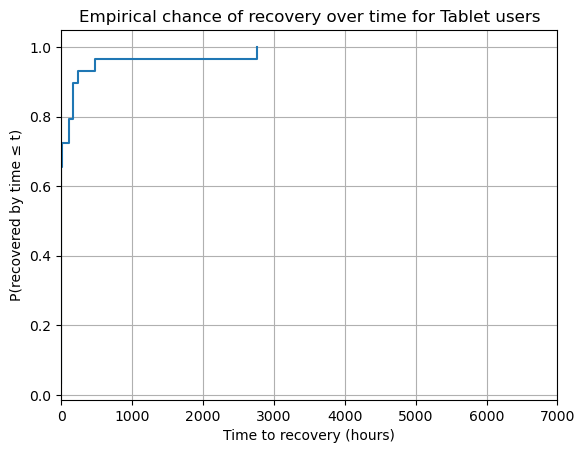


=== Combined Recovery Probability Table ===


,1h,6h,12h,24h,48h,72h
Desktop,0.492036,0.579067,0.589306,0.614334,0.649033,0.673493
Mobile,0.562358,0.625850,0.628118,0.657596,0.696145,0.712018
Tablet,0.620690,0.724138,0.724138,0.724138,0.724138,0.724138


In [23]:
#Test each device category

desktop_tbl = analyze_device(GARecovered,'device_category', "Desktop")
mobile_tbl  = analyze_device(GARecovered,'device_category', "Mobile")
tablet_tbl  = analyze_device(GARecovered,'device_category', "Tablet")

# combine the results into a single table
recovery_summary = pd.concat([desktop_tbl, mobile_tbl, tablet_tbl])
print("\n=== Combined Recovery Probability Table ===")
display(recovery_summary)



As we can see from the summarized table above, desktop recovers the slowest and tablet users recover the fastest. However, after the 3 day mark, we don't see much of a difference between the 3 devices. 

One thing to note, is that if a tablet user has yet to recover by 6 hours, they won't for 3 days. Whereas desktop and mobile users increase recovery slowly over time.

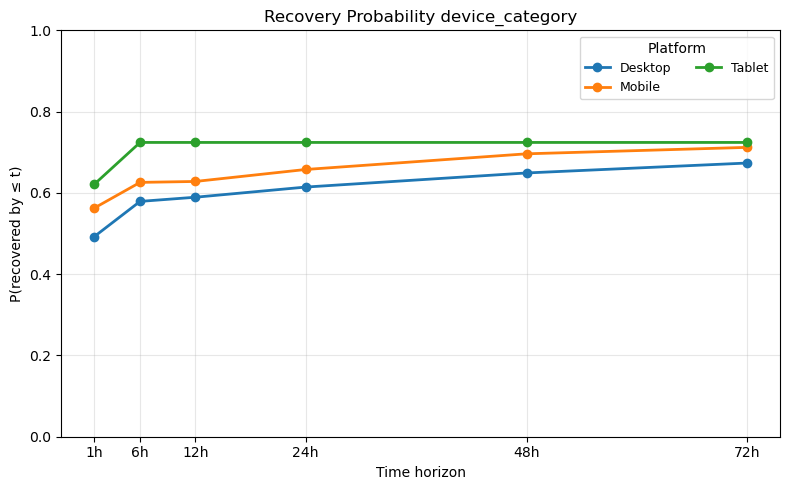

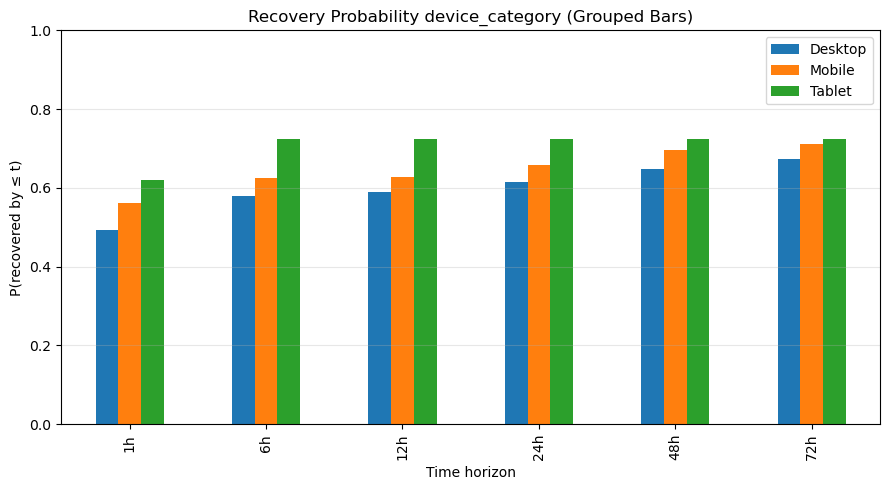

In [24]:
plot_recovery_summary(recovery_summary,'device_category')

As we can see above, tablet users have the highest chances of recovery, with mobile users in the middle, and desktop having the lowest chance. The chances of recovery diminish very quickly across all devices as the rate barely increases from 12h to 72h.

### Step 3.2 Rate of recovery by device_mobile_brand_name


=== Duration summary (hours) for Google ===
count     968.000000
mean      207.832622
std       564.589615
min         0.000000
25%         0.122528
50%         0.919528
75%       146.774300
max      5424.963747
Name: duration_hours, dtype: float64


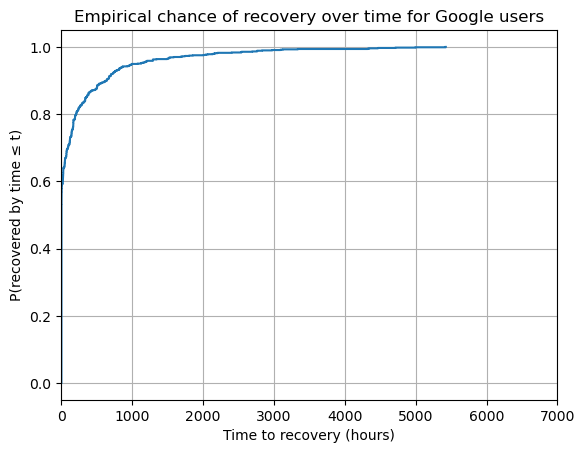


=== Duration summary (hours) for Apple ===
count     639.000000
mean      344.046978
std       951.769261
min         0.000000
25%         0.103547
50%         1.014866
75%       168.240614
max      7038.238264
Name: duration_hours, dtype: float64


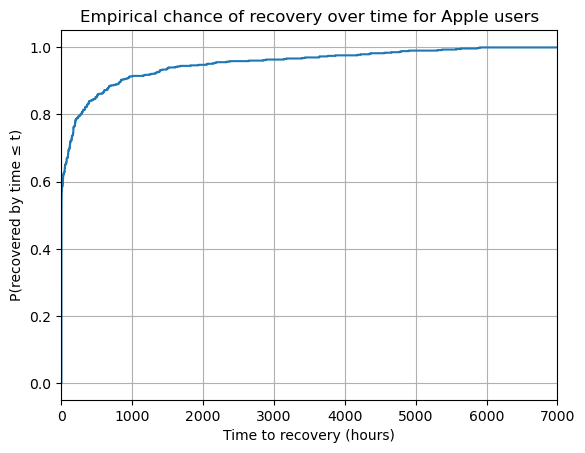


=== Duration summary (hours) for Microsoft ===
count     509.000000
mean      175.888369
std       545.100954
min         0.001677
25%         0.126392
50%         0.569571
75%        99.618822
max      4945.921363
Name: duration_hours, dtype: float64


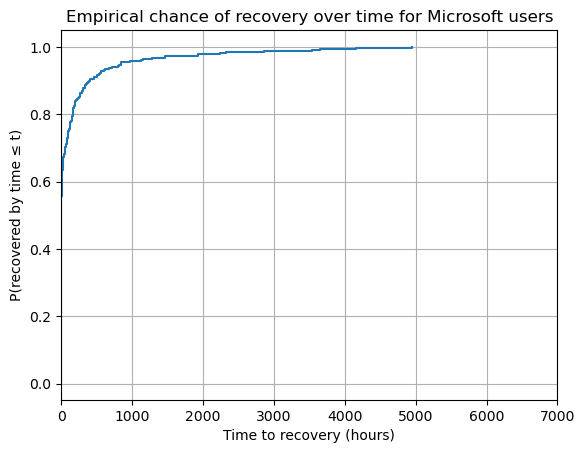


=== Duration summary (hours) for Samsung ===
count     104.000000
mean      200.278715
std       682.557613
min         0.000000
25%         0.091644
50%         0.392611
75%       114.104418
max      5346.058448
Name: duration_hours, dtype: float64


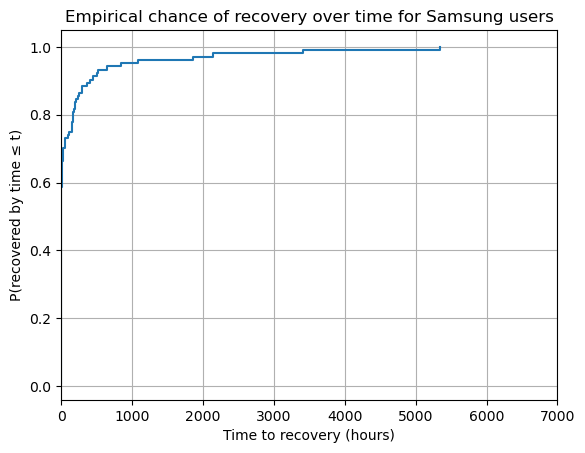


=== Duration summary (hours) for Mozilla ===
count     24.000000
mean      81.976669
std      200.795846
min        0.038871
25%        0.199903
50%        0.282298
75%        3.644726
max      824.936201
Name: duration_hours, dtype: float64


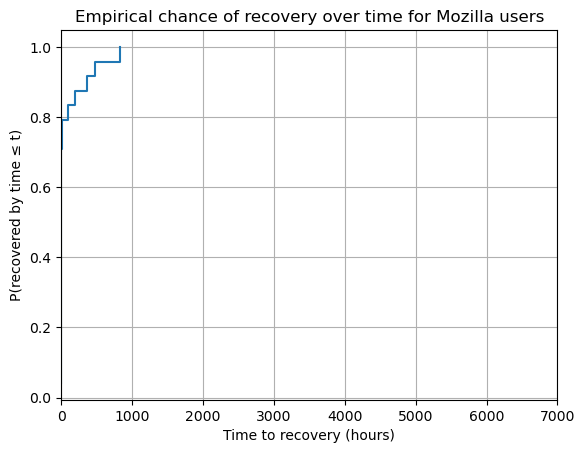


=== Duration summary (hours) for Other ===
count      31.000000
mean      133.679986
std       388.655161
min         0.000000
25%         0.045924
50%         0.095600
75%         2.111268
max      2004.419694
Name: duration_hours, dtype: float64


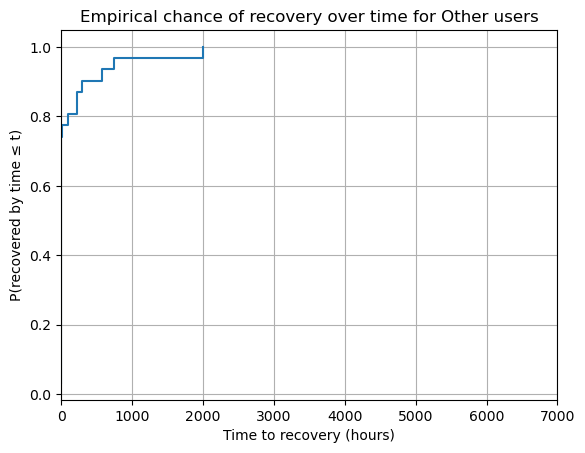


=== Duration summary (hours) for Samsung ===
count     104.000000
mean      200.278715
std       682.557613
min         0.000000
25%         0.091644
50%         0.392611
75%       114.104418
max      5346.058448
Name: duration_hours, dtype: float64


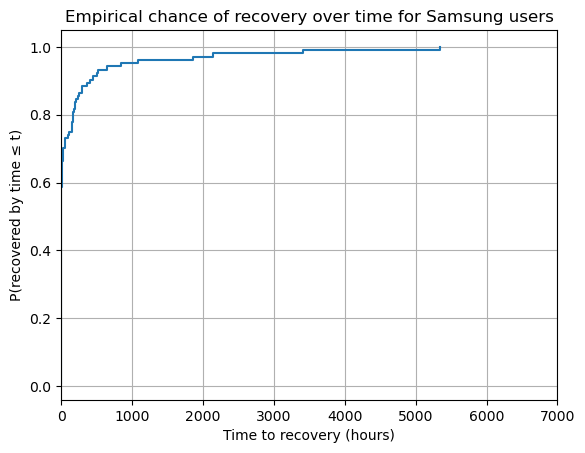


=== Combined Recovery Probability Table ===


,1h,6h,12h,24h,48h,72h
Google,0.503099,0.586777,0.591942,0.615702,0.657025,0.688017
Apple,0.499218,0.574335,0.583725,0.613459,0.640063,0.657277
Microsoft,0.536346,0.620825,0.634578,0.658153,0.695481,0.711198
Samsung,0.567308,0.653846,0.653846,0.692308,0.711538,0.730769
Mozilla,0.708333,0.791667,0.791667,0.791667,0.791667,0.791667
Other,0.741935,0.774194,0.774194,0.774194,0.774194,0.774194
Samsung,0.567308,0.653846,0.653846,0.692308,0.711538,0.730769


In [25]:
#Test each device category

google = analyze_device(GARecovered,'device_mobile_brand_name', "Google")
apple  = analyze_device(GARecovered,'device_mobile_brand_name', "Apple")
Microsoft  = analyze_device(GARecovered,'device_mobile_brand_name', "Microsoft")
Samsung  = analyze_device(GARecovered,'device_mobile_brand_name', "Samsung")
Mozilla  = analyze_device(GARecovered,'device_mobile_brand_name', "Mozilla")
Other  = analyze_device(GARecovered,'device_mobile_brand_name', "Other")
Samsung  = analyze_device(GARecovered,'device_mobile_brand_name', "Samsung")


# combine the results into a single table
recovery_summary = pd.concat([google, apple, Microsoft, Samsung, Mozilla, Other, Samsung])
print("\n=== Combined Recovery Probability Table ===")
display(recovery_summary)

As we can see from the summarized table above, Google users recover the slowest and and Other users recover the fastest. Mozilla users are second to fastest.  

One thing to note, is that if a Other user has yet to recover by 6 hours, they won't for 3 days. Whereas the rest slowly still increase recovery overy time.

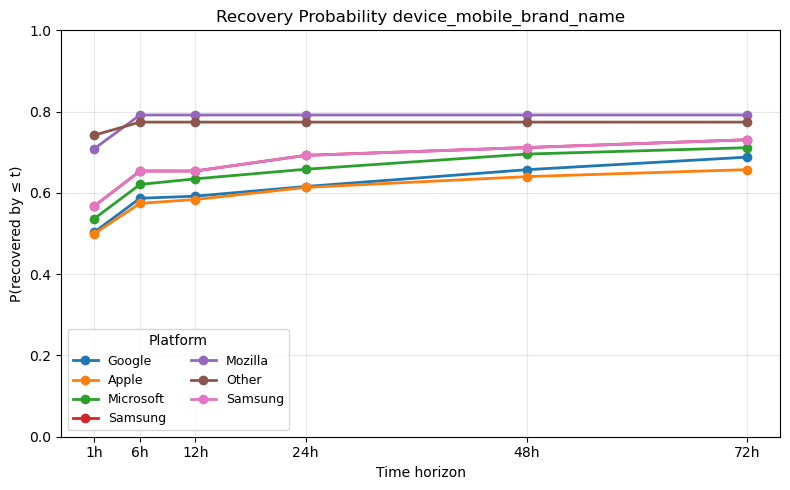

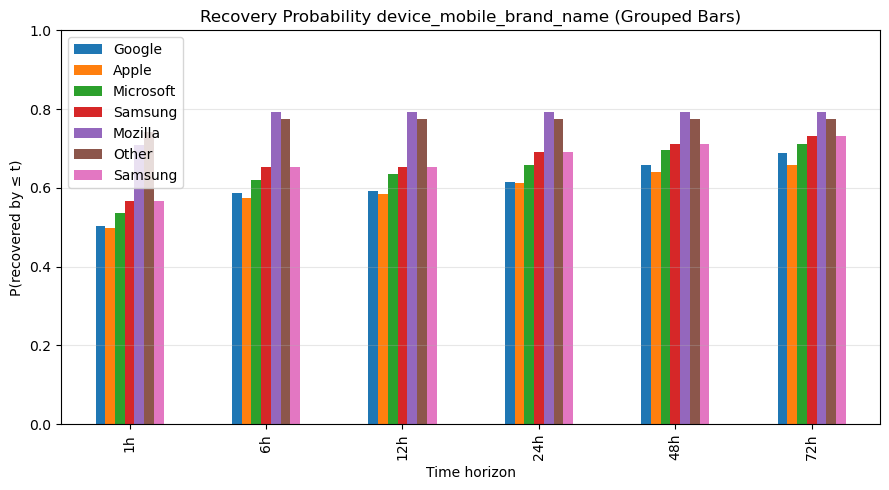

In [26]:
plot_recovery_summary(recovery_summary,'device_mobile_brand_name')

Clearly, Mozilla and Other have the highest rates of recovery. The rest are slightly lower, but still all have diminishing returns over time.

### Step 3.3 Rate of recovery by device_operating_system


=== Duration summary (hours) for Windows ===
count    1399.000000
mean      204.031368
std       562.152872
min         0.000000
25%         0.140345
50%         1.127036
75%       147.849708
max      5424.963747
Name: duration_hours, dtype: float64


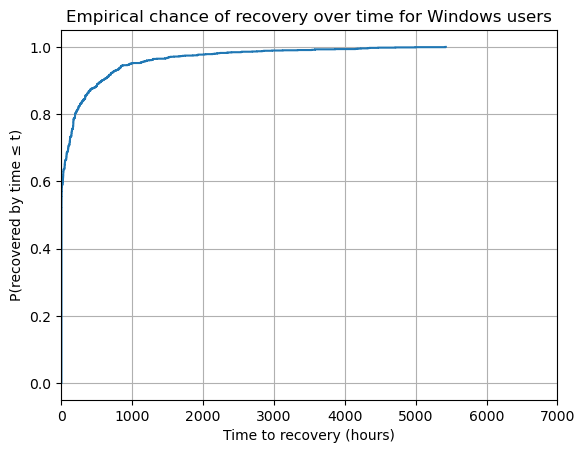


=== Duration summary (hours) for iOS ===
count     328.000000
mean      343.053472
std      1018.429759
min         0.000000
25%         0.083820
50%         0.437942
75%       142.483545
max      7038.238264
Name: duration_hours, dtype: float64


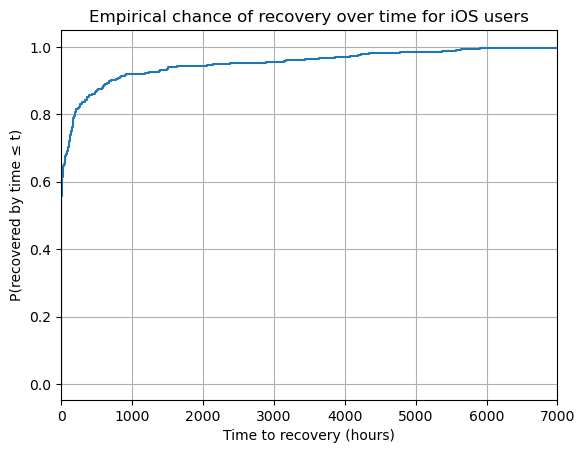


=== Duration summary (hours) for Macintosh ===
count     332.000000
mean      244.306404
std       692.713007
min         0.000000
25%         0.107682
50%         0.710376
75%       134.588669
max      5309.007256
Name: duration_hours, dtype: float64


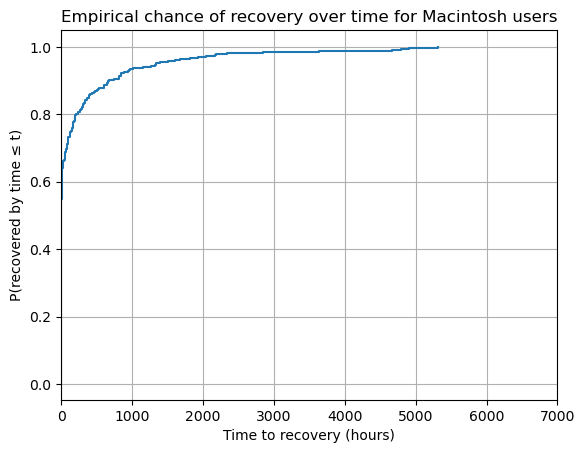


=== Duration summary (hours) for Android ===
count     139.000000
mean      188.672868
std       712.950909
min         0.000000
25%         0.077406
50%         0.352330
75%        47.624899
max      5346.058448
Name: duration_hours, dtype: float64


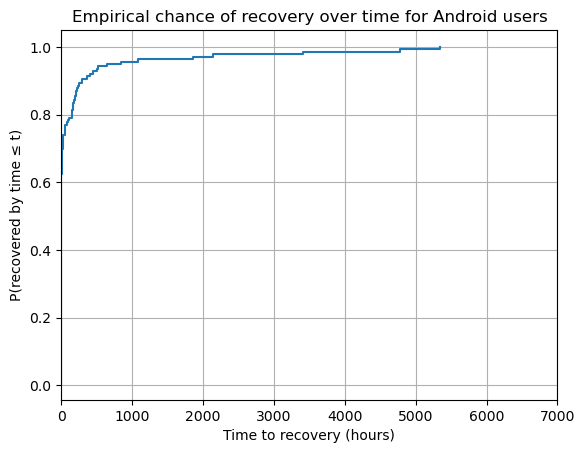


=== Duration summary (hours) for Chrome OS ===
count      53.000000
mean      150.000377
std       408.641786
min         0.014072
25%         0.135937
50%         0.597816
75%       143.623515
max      2761.479862
Name: duration_hours, dtype: float64


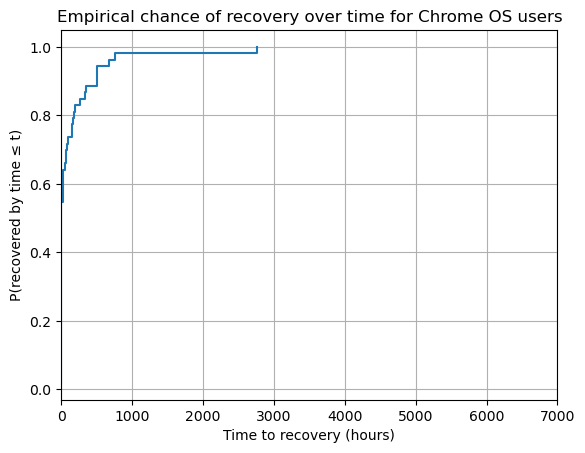


=== Combined Recovery Probability Table ===


,1h,6h,12h,24h,48h,72h
Windows,0.495354,0.581844,0.589707,0.611866,0.652609,0.676912
iOS,0.548780,0.603659,0.606707,0.631098,0.667683,0.682927
Macintosh,0.524096,0.620482,0.638554,0.662651,0.674699,0.695783
Android,0.604317,0.690647,0.690647,0.726619,0.748201,0.769784
Chrome OS,0.528302,0.547170,0.547170,0.622642,0.660377,0.698113


In [27]:
#Test each device category

windows = analyze_device(GARecovered,'device_operating_system', "Windows")
iOS  = analyze_device(GARecovered,'device_operating_system', "iOS")
Macintosh  = analyze_device(GARecovered,'device_operating_system', "Macintosh")
Android  = analyze_device(GARecovered,'device_operating_system', "Android")
Chrome  = analyze_device(GARecovered,'device_operating_system', "Chrome OS")


# combine the results into a single table
recovery_summary = pd.concat([windows, iOS, Macintosh, Android, Chrome])
print("\n=== Combined Recovery Probability Table ===")
display(recovery_summary)

As we can see from the summarized table above, Windows users recover the slowest and and Android users recover the fastest. They all slowly increase recovery over time.

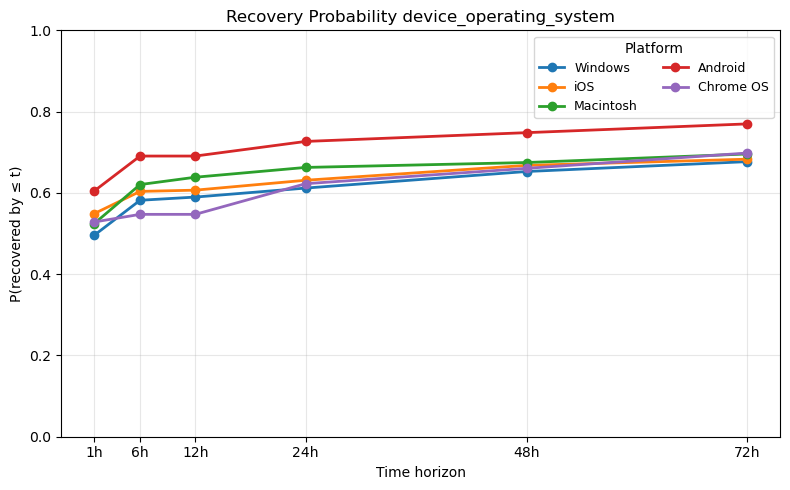

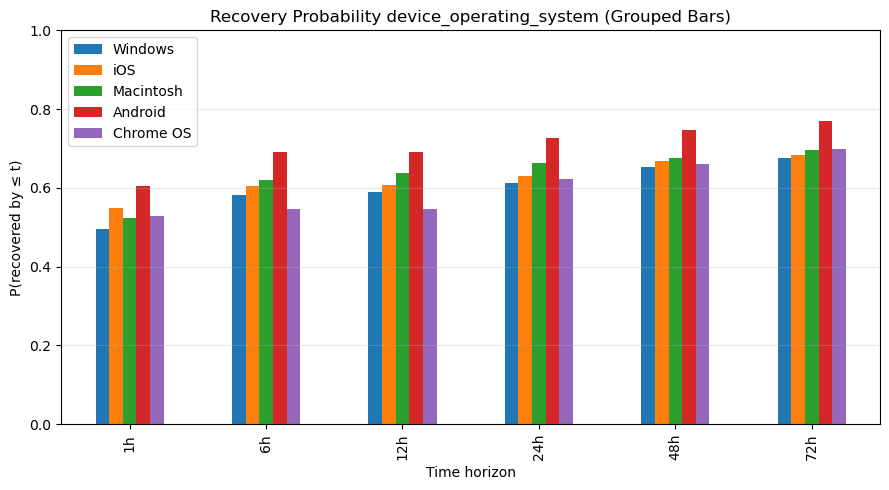

In [28]:
plot_recovery_summary(recovery_summary,'device_operating_system')

As we can see from the plot above, Android users clearly recover more in a shorter timeframe than the rest, who seem to have similar recovery rates over time.